# DeepSDF Airport - Run final surveillé


## Cell 1 - Paramètres d'exécution


In [1]:
USE_GOOGLE_DRIVE = True
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/deepsdf_airport"
RUN_NAME = "COLAB_RUN_final"

BASE_CONFIG_FILE = "config.yaml"
RUNTIME_CONFIG_FILE = "config_runtime.yaml"

USE_TEST_CUBE = False
CLEAN_START = True

## Cell 2 - Préparation du workspace et de Drive


In [2]:
import os
import sys
import json
import shutil
from pathlib import Path
import yaml

IN_COLAB = "google.colab" in sys.modules
SOURCE_DIR = Path.cwd()

if IN_COLAB and USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    SOURCE_DIR = Path(DRIVE_PROJECT_DIR)

WORK_DIR = Path("/content/deepsdf_airport") if IN_COLAB else (SOURCE_DIR / RUN_NAME)
DRIVE_RUN_DIR = (Path(DRIVE_PROJECT_DIR) / RUN_NAME) if (IN_COLAB and USE_GOOGLE_DRIVE) else (SOURCE_DIR / RUN_NAME)

if CLEAN_START and WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)
WORK_DIR.mkdir(parents=True, exist_ok=True)

for sub in ["data/meshes", "data/sdf_dataset", "checkpoints", "outputs", "data_sources"]:
    (WORK_DIR / sub).mkdir(parents=True, exist_ok=True)

required_files = [
    "config.yaml",
    "requirements.txt",
    "utils.py",
    "openalaqs_import.py",
    "data_ingestion.py",
    "prepare_runtime_config.py",
    "sdf_sampling.py",
    "deepsdf_model.py",
    "train.py",
    "visualize.py",
    "generate_mask.py",
    "evaluate_reconstruction.py",
    "check_openalaqs_study.py",
    "COLAB_TRAINING_final.ipynb",
]
missing = [name for name in required_files if not (SOURCE_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f"Fichiers manquants dans la source : {missing}")

for name in required_files:
    shutil.copy2(SOURCE_DIR / name, WORK_DIR / name)

with open(SOURCE_DIR / BASE_CONFIG_FILE, "r", encoding="utf-8") as f:
    base_cfg = yaml.safe_load(f)

study_candidates = []
declared = base_cfg.get("airport", {}).get("open_alaqs_database", "") or base_cfg.get("airport", {}).get("open_alaqs_study", "")
if declared:
    study_candidates.append(SOURCE_DIR / declared)
study_candidates.append(SOURCE_DIR / "data_sources" / "airport_study.alaqs")
study_candidates.append(SOURCE_DIR / "airport_study.alaqs")

study_src = None
for candidate in study_candidates:
    if candidate.exists():
        study_src = candidate
        break

if not USE_TEST_CUBE:
    if study_src is None:
        raise FileNotFoundError("Aucune étude OpenALAQS trouvée. Attendu : airport_study.alaqs")
    study_dst = WORK_DIR / "data_sources" / "airport_study.alaqs"
    shutil.copy2(study_src, study_dst)
    base_cfg.setdefault("airport", {})["open_alaqs_database"] = "data_sources/airport_study.alaqs"

with open(WORK_DIR / BASE_CONFIG_FILE, "w", encoding="utf-8") as f:
    yaml.safe_dump(base_cfg, f, sort_keys=False, allow_unicode=True)

prof_src = SOURCE_DIR / "prof_files"
if prof_src.exists():
    shutil.copytree(prof_src, WORK_DIR / "prof_files", dirs_exist_ok=True)

os.chdir(WORK_DIR)
print("Workspace prêt :", WORK_DIR)
print("Run Drive     :", DRIVE_RUN_DIR)
if not USE_TEST_CUBE:
    print("Étude utilisée :", (WORK_DIR / "data_sources" / "airport_study.alaqs").resolve())

Mounted at /content/drive
Workspace prêt : /content/deepsdf_airport
Run Drive     : /content/drive/MyDrive/deepsdf_airport/COLAB_RUN_final
Étude utilisée : /content/deepsdf_airport/data_sources/airport_study.alaqs


## Cell 3 - Dépendances


In [3]:
import sys
!{sys.executable} -m pip install -q -r requirements.txt
print("Dépendances prêtes.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 12.6 MB/s eta 0:00:00
Dépendances prêtes.


## Cell 4 - Préflight global


In [4]:
import importlib
import subprocess
from pathlib import Path

required_modules = [
    "torch", "numpy", "trimesh", "shapely", "yaml", "scipy",
    "skimage", "matplotlib", "imageio", "imageio_ffmpeg", "rtree"
]
for name in required_modules:
    mod = importlib.import_module(name)
    print(f"{name}: {getattr(mod, '__version__', 'unknown')}")

if USE_TEST_CUBE:
    print("Mode test cube actif.")
else:
    study_path = Path("data_sources/airport_study.alaqs")
    assert study_path.exists(), f"Étude introuvable : {study_path}"
    subprocess.run([sys.executable, "check_openalaqs_study.py", str(study_path)], check=True)

import torch
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
else:
    print("GPU non détecté, exécution CPU.")

torch: 2.10.0+cu128
numpy: 2.0.2
trimesh: 4.11.5
shapely: 2.1.2
yaml: 6.0.3
scipy: 1.16.3
skimage: 0.25.2
matplotlib: 3.10.0
imageio: 2.37.3
imageio_ffmpeg: 0.6.0
rtree: 1.4.1
GPU : Tesla T4
VRAM: 15.6 GB


## Cell 5 - Ingestion et extrusion 3D


In [5]:
extra_args = "--test-cube" if USE_TEST_CUBE else ""
!python data_ingestion.py --config {BASE_CONFIG_FILE} {extra_args}

=== Loading OpenALAQS study for Paris-Orly ===
  Database source: /content/deepsdf_airport/data_sources/airport_study.alaqs
  OpenALAQS layer counts: {'buildings': 0, 'gates': 0, 'runways': 0, 'taxiways': 0, 'roadways': 0, 'parking': 0, 'area_sources': 0, 'point_sources': 0}
  No buildings found in OpenALAQS. Falling back to the next available source.
=== Downloading terminal/building footprints for Paris-Orly ===
  Querying Overpass API (radius=1500 m)...
  Attempt 1/3 failed: 504 Server Error: Gateway Timeout for url: https://overpass-api.de/api/interpreter
  Got 7070 OSM elements.
  Parsed 672 valid OSM terminal/building polygons.
  Extruding 672 polygons...
  672 meshes created.
  Saved -> /content/deepsdf_airport/data/meshes/Paris-Orly_buildings.obj
  Stats: 672 buildings, 11,252 vertices, 19,816 faces
  OpenALAQS reference summary -> /content/deepsdf_airport/data/meshes/openalaqs_reference_layers.json
=== Done ===


## Cell 6 - Adaptation du domaine


In [6]:
!python prepare_runtime_config.py --config {BASE_CONFIG_FILE} --output {RUNTIME_CONFIG_FILE}

from pathlib import Path
import json
import yaml

summary_path = Path(RUNTIME_CONFIG_FILE.replace(".yaml", "_preparation.json"))
with open(RUNTIME_CONFIG_FILE, "r", encoding="utf-8") as f:
    runtime_cfg = yaml.safe_load(f)

print("Configuration runtime prête :", RUNTIME_CONFIG_FILE)
print("Domaine runtime :", runtime_cfg["domain"])
print("Training runtime:", runtime_cfg["training"])
print("Monitoring      :", runtime_cfg["monitoring"])
if summary_path.exists():
    prep = json.loads(summary_path.read_text(encoding="utf-8"))
    print("BBox mesh min/max :", prep["mesh_bbox_min"], prep["mesh_bbox_max"])
    print("Span XYZ [m]      :", prep["mesh_span_xyz_m"])

Runtime configuration ready.
  Config  : config_runtime.yaml
  Summary : config_runtime_preparation.json
  Domain  : {'x_min': -1693.634, 'x_max': 1503.391, 'y_min': -1631.161, 'y_max': 1676.684, 'z_max': 48.0, 'grid_nx': 321, 'grid_ny': 321, 'grid_nz': 65}
Configuration runtime prête : config_runtime.yaml
Domaine runtime : {'x_min': -1693.634, 'x_max': 1503.391, 'y_min': -1631.161, 'y_max': 1676.684, 'z_max': 48.0, 'grid_nx': 321, 'grid_ny': 321, 'grid_nz': 65}
Training runtime: {'batch_size': 16384, 'learning_rate': 0.0002, 'n_epochs': 200, 'clamp_delta': 2.0, 'lr_scheduler': 'cosine', 'save_every_n_epochs': 20, 'device': 'cuda', 'validation_fraction': 0.03, 'seed': 42, 'num_workers': 4, 'gradient_clip': 1.0, 'early_stopping_patience': 50, 'surface_zero_eps': 1e-05, 'surface_focus_band': 0.5}
Monitoring      : {'enabled': True, 'every_n_epochs': 20, 'warmup_epochs': 20, 'fail_fast_after_epoch': 60, 'collapse_patience': 5, 'min_pred_std': 0.02, 'max_surface_ratio_to_baseline_after_war

## Cell 7 - Échantillonnage SDF


In [7]:
!python sdf_sampling.py --config {RUNTIME_CONFIG_FILE}

=== Loading meshes ===
  Loaded Paris-Orly_buildings.obj: 11,252 verts / 19,816 faces
  Combined: 11,252 verts / 19,816 faces
  Watertight: True  (False is normal for a multi-building scene)
  2D footprint metadata loaded for 672 buildings
  Normalisation: center=[-95.12149810791016, 22.761499404907227, 24.0], scale=1653.92 m

=== Sampling 250,000 surface points ===
  250,000 surface points kept within domain (100.0%)

=== Sampling 1,600,000 near-surface points (σ=1.240 m) ===
  Computing SDF for near-surface points…
                                            
=== Sampling 250,000 random domain points ===
  Computing SDF for far points…

=== Dataset saved ===
  Shape  : (2100000, 4)
  Path   : /content/deepsdf_airport/data/sdf_dataset/sdf_dataset.pt
  Coords : [-1.000, 1.000]  (normalised)
  SDF    : [-2.0000, 2.0000]
  Inside : 35.0% of points
  |SDF| mean       : 0.7879
  |SDF| median     : 0.5832
  Exact surface    : 24.9%
  Near surface <0.5: 46.7%
  Near surface <1.0: 64.2%
  Cla

## Cell 8 - Vérification du dataset


In [8]:
import json
from pathlib import Path
import torch

ds_path = Path("data/sdf_dataset/sdf_dataset.pt")
norm_path = Path("data/sdf_dataset/normalization.json")
assert ds_path.exists(), f"Dataset introuvable : {ds_path}"
assert norm_path.exists(), f"Normalisation introuvable : {norm_path}"

ds = torch.load(ds_path, map_location="cpu")
abs_sdf = ds[:, 3].abs()
inside_pct = (ds[:, 3] < 0).float().mean().item() * 100
clamped_pct = (abs_sdf >= abs_sdf.max() * 0.99).float().mean().item() * 100

print(f"Shape            : {tuple(ds.shape)}")
print(f"Coords           : [{ds[:, :3].min().item():.3f}, {ds[:, :3].max().item():.3f}]")
print(f"SDF              : [{ds[:,3].min().item():.4f}, {ds[:,3].max().item():.4f}]")
print(f"Inside           : {inside_pct:.2f}%")
print(f"|SDF| mean       : {abs_sdf.mean().item():.4f}")
print(f"|SDF| median     : {abs_sdf.median().item():.4f}")
print(f"Near surface <0.5: {(abs_sdf <= 0.5).float().mean().item() * 100:.2f}%")
print(f"Clamped approx   : {clamped_pct:.2f}%")

assert ds[:, :3].max().item() <= 1.1, "Coordonnées normalisées hors plage."
assert inside_pct >= 0.5, "Trop peu de points intérieurs : vérifier ingestion / signe du SDF."
assert (abs_sdf <= 0.5).float().mean().item() >= 0.10, "Pas assez de points proches de la surface."

Shape            : (2100000, 4)
Coords           : [-1.000, 1.000]
SDF              : [-2.0000, 2.0000]
Inside           : 34.98%
|SDF| mean       : 0.7879
|SDF| median     : 0.5832
Near surface <0.5: 46.71%
Clamped approx   : 17.39%


## Cell 9 - Entraînement surveillé


In [9]:
import os
import sys
import json
import subprocess
from pathlib import Path

os.environ["DEEPSDF_MIRROR_DIR"] = str(DRIVE_RUN_DIR)
cmd = [sys.executable, "-u", "train.py", "--config", RUNTIME_CONFIG_FILE]
process = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

log_lines = []
assert process.stdout is not None
for line in process.stdout:
    print(line, end="")
    log_lines.append(line)

return_code = process.wait()
console_log = Path("checkpoints/train_console.log")
console_log.write_text("".join(log_lines), encoding="utf-8")
print("Console log sauvegardé dans", console_log)

if return_code != 0:
    failure_path = Path("checkpoints/training_failure.json")
    if failure_path.exists():
        failure = json.loads(failure_path.read_text(encoding="utf-8"))
        print("\nDiagnostic d'arrÃªtÃ©:")
        print(json.dumps(failure, indent=2, ensure_ascii=False))
    raise RuntimeError(f"train.py s'est arr?t? avec le code {return_code}")


Device: cuda
  GPU: Tesla T4
/content/deepsdf_airport/train.py:582: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=True)
  AMP enabled : True
  AMP dtype   : float16

Loading dataset: /content/deepsdf_airport/data/sdf_dataset/sdf_dataset.pt

Dataset diagnostics:
  mean(|sdf|)            : 0.787887
  median(|sdf|)          : 0.583201
  exact surface zeros    : 24.92%
  near-surface non-zero  : 21.79%
  clamped far samples    : 17.39%
  2,100,000 points loaded
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slow

## Cell 10 - Lecture structurée de l'entraînement


In [10]:
import json
from pathlib import Path

summary = json.loads(Path("checkpoints/training_summary.json").read_text(encoding="utf-8"))
recommendation = json.loads(Path("checkpoints/checkpoint_recommendation.json").read_text(encoding="utf-8"))

print("Résumé training :")
print(json.dumps(summary, indent=2, ensure_ascii=False))
print("\nCheckpoint recommandé :")
print(json.dumps(recommendation, indent=2, ensure_ascii=False))

required_logs = [
    "checkpoints/history.json",
    "checkpoints/training_epochs.json",
    "checkpoints/training_epochs.jsonl",
    "checkpoints/training_epochs.csv",
    "checkpoints/training_summary.json",
    "checkpoints/checkpoint_recommendation.json",
]
missing = [p for p in required_logs if not Path(p).exists()]
if missing:
    raise FileNotFoundError(f"Logs manquants : {missing}")
print("Tous les logs principaux sont présents.")


Résumé training :
{
  "status": "completed",
  "best_epoch_selection": 190,
  "best_selection_loss": 0.07739491015672684,
  "best_val_epoch": 196,
  "best_val_loss": 0.13943183794617653,
  "best_surface_epoch": 190,
  "best_surface_loss": 0.07739491015672684,
  "latest_epoch": 200,
  "latest_val_loss": 0.1394498087465763,
  "latest_surface_loss": 0.07747513987123966,
  "latest_zero_baseline_loss": 0.7831820398569107,
  "n_epochs_requested": 200,
  "n_epochs_run": 200,
  "validation_fraction": 0.03,
  "monitor_probes_run": 10,
  "best_geometry": {
    "monitor_status": "ok",
    "reference_obstacle_voxels_monitor": 11354,
    "boundary_fraction": 0.017902813299232736,
    "fragmentation_ratio": 0.0,
    "occupancy_level": -1.166235089302063,
    "occupancy_level_source": "matched_reference_voxel_count",
    "target_obstacle_voxels": 11354,
    "predicted_obstacle_voxels_at_level": 12488,
    "raw_negative_fraction": 0.04316947115384615,
    "thresholded_negative_fraction": 0.00750480769

## Cell 11 - Validation géométrique


In [11]:
import json
from pathlib import Path

recommendation = json.loads(Path("checkpoints/checkpoint_recommendation.json").read_text(encoding="utf-8"))
SELECTED_CHECKPOINT = recommendation["recommended_checkpoint"]
print("Checkpoint utilisé pour l'évaluation :", SELECTED_CHECKPOINT)
!python evaluate_reconstruction.py --config {RUNTIME_CONFIG_FILE} --checkpoint {SELECTED_CHECKPOINT}

Checkpoint utilisé pour l'évaluation : checkpoints/best_geometry.pt
  Loaded Paris-Orly_buildings.obj: 11,252 verts / 19,816 faces
Device: cuda
Evaluating SDF on validation grid...
Cleaning predicted occupancy...
Reconstructing cleaned mesh with marching cubes...
Computing Chamfer-style reconstruction metrics...
Computing occupancy metrics on the simulation grid...

Reconstruction metrics
  reference_vertices: 11252
  reference_faces: 19816
  predicted_vertices: 20388
  predicted_faces: 40620
  chamfer_l1_m: 123.69040116245327
  chamfer_l2_m2: 39091.01469019479
  hausdorff_approx_m: 675.2299937400601
  occupancy_iou: 0.37452938916634654
  occupancy_precision: 0.7877661508625914
  occupancy_recall: 0.4165616253979106
  occupancy_tp: 19498
  occupancy_tn: 6645605
  occupancy_fp: 5253
  occupancy_fn: 27309
  predicted_obstacle_voxels: 24751
  reference_obstacle_voxels: 46807
  occupancy_level: -1.1512782573699951
  occupancy_level_source: matched_reference_voxel_count
  target_obstacle_vo

## Cell 12 - Visualisation finale


In [12]:
!python visualize.py --config {RUNTIME_CONFIG_FILE} --checkpoint {SELECTED_CHECKPOINT}

Device: cuda
Model loaded from /content/deepsdf_airport/checkpoints/best_geometry.pt
Rendering mesh view: Front X...
Rendering mesh view: Front Y...
Rendering mesh view: Diagonal...
Rendering mesh view: Top-down...
Render grid -> /content/deepsdf_airport/outputs/renders_grid.png
SDF slice z=0.05 -> /content/deepsdf_airport/outputs/sdf_slice_z005.png
SDF slice z=0.20 -> /content/deepsdf_airport/outputs/sdf_slice_z020.png
SDF slice z=0.50 -> /content/deepsdf_airport/outputs/sdf_slice_z050.png
Loss curves -> /content/deepsdf_airport/outputs/training_loss.png
Monitoring curves -> /content/deepsdf_airport/outputs/monitoring_curves.png
Generating flyover video...
  12/72 frames done
  24/72 frames done
  36/72 frames done
  48/72 frames done
  60/72 frames done
  72/72 frames done
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 600) to (608, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your 

## Cell 13 - Lecture des résultats principaux


Métriques de reconstruction :
{
  "reference_vertices": 11252,
  "reference_faces": 19816,
  "predicted_vertices": 20388,
  "predicted_faces": 40620,
  "chamfer_l1_m": 123.69040116245327,
  "chamfer_l2_m2": 39091.01469019479,
  "hausdorff_approx_m": 675.2299937400601,
  "occupancy_iou": 0.37452938916634654,
  "occupancy_precision": 0.7877661508625914,
  "occupancy_recall": 0.4165616253979106,
  "occupancy_tp": 19498,
  "occupancy_tn": 6645605,
  "occupancy_fp": 5253,
  "occupancy_fn": 27309,
  "predicted_obstacle_voxels": 24751,
  "reference_obstacle_voxels": 46807,
  "occupancy_level": -1.1512782573699951,
  "occupancy_level_source": "matched_reference_voxel_count",
  "target_obstacle_voxels": 46807,
  "predicted_obstacle_voxels_at_level": 51487,
  "raw_negative_fraction": 0.04343230066000613,
  "thresholded_negative_fraction": 0.0076873059491628795,
  "cleaned_negative_fraction": 0.0036954670023060274,
  "n_components": 2415,
  "boundary_component_count": 27,
  "grounded_component_co

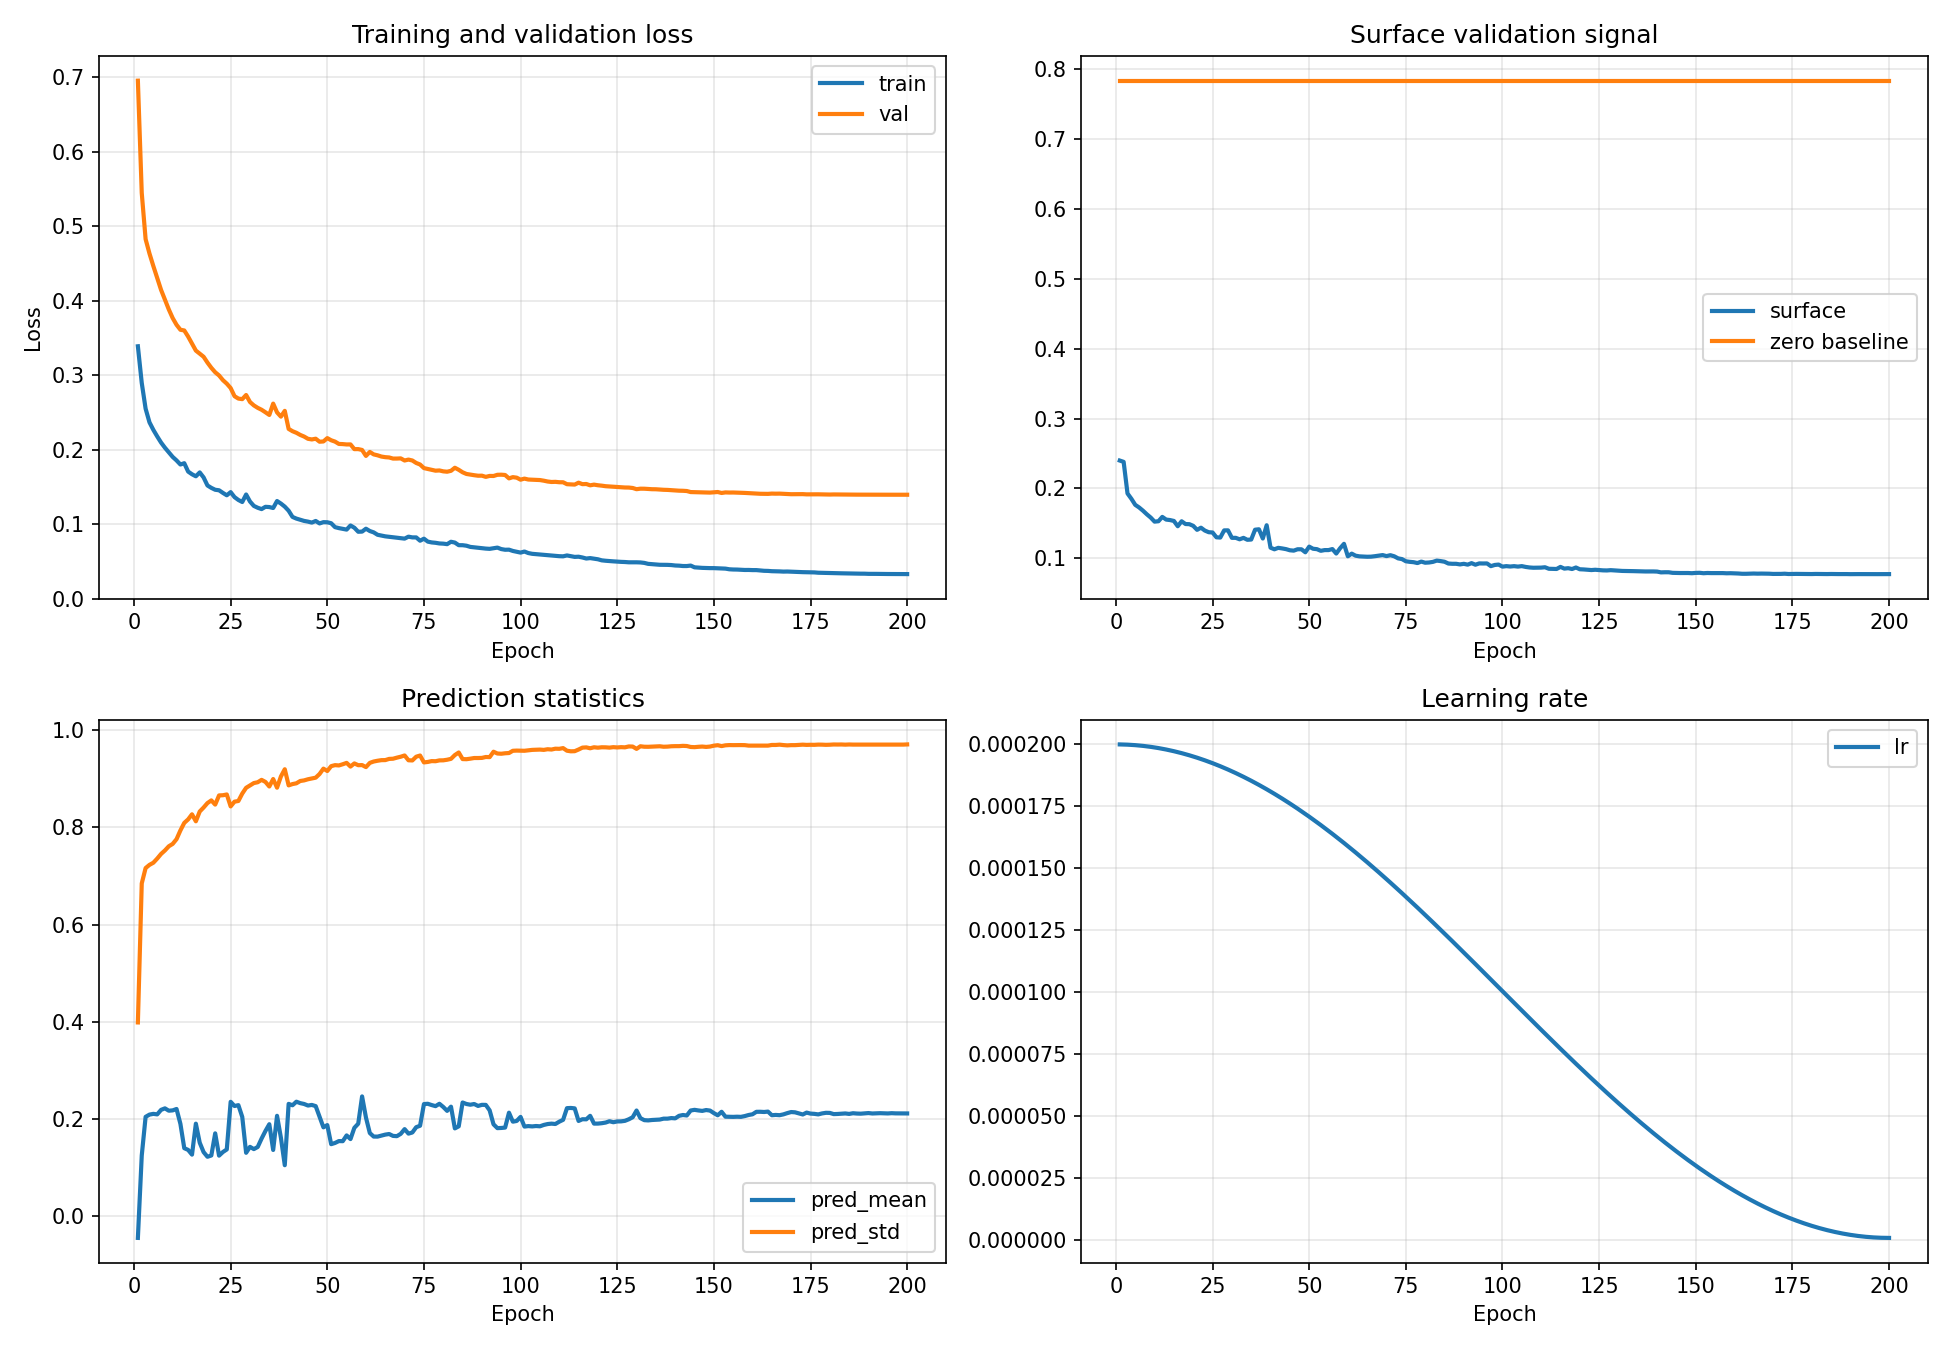


-- monitoring_curves.png


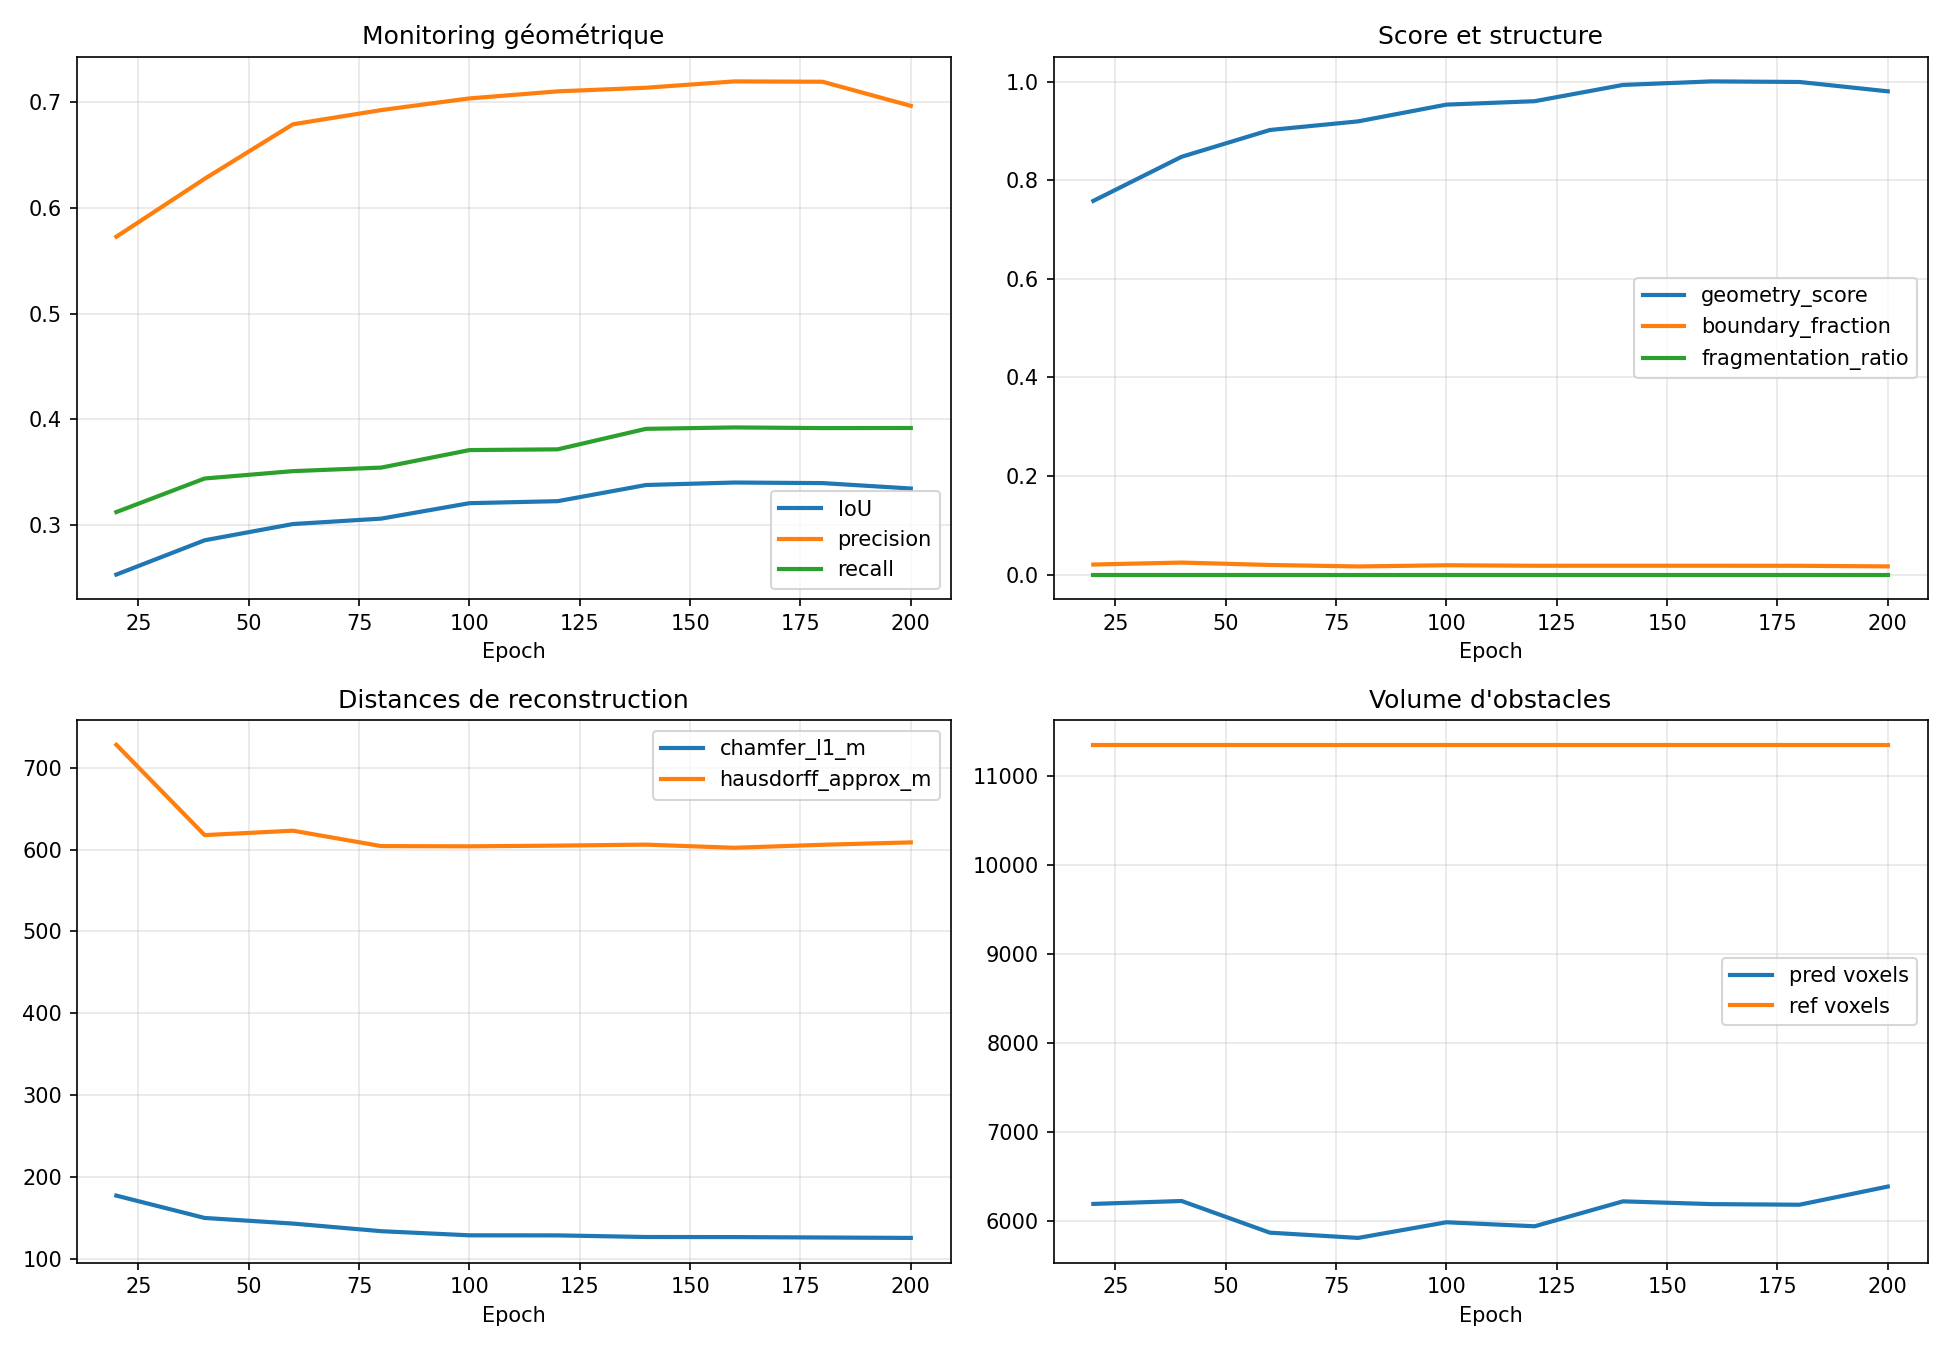


-- reconstruction_comparison.png


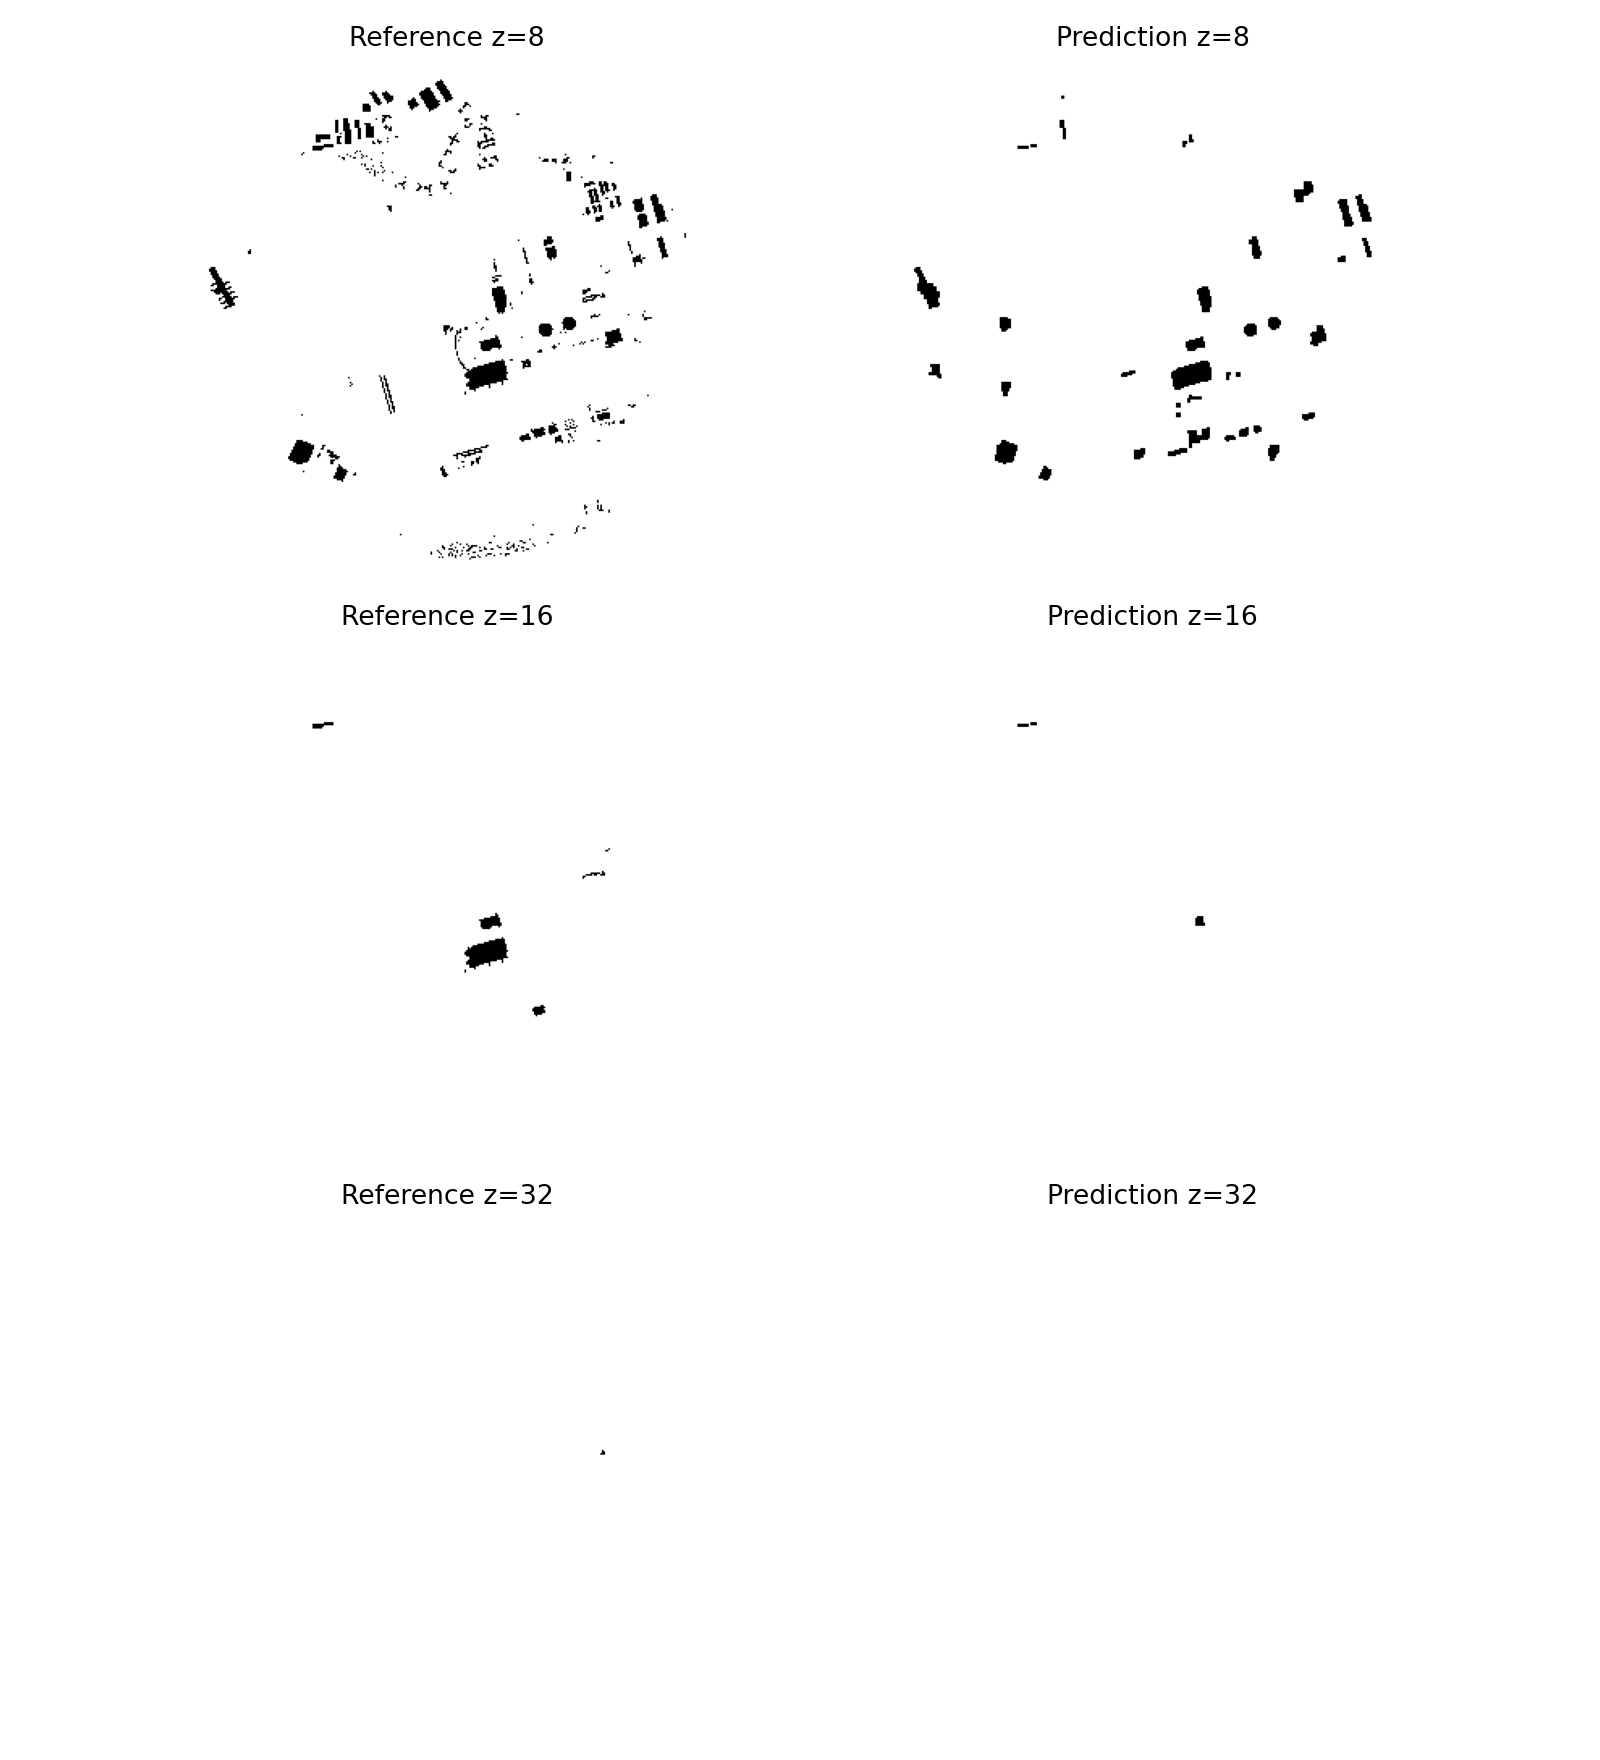


-- occupancy_confusion_matrix.png


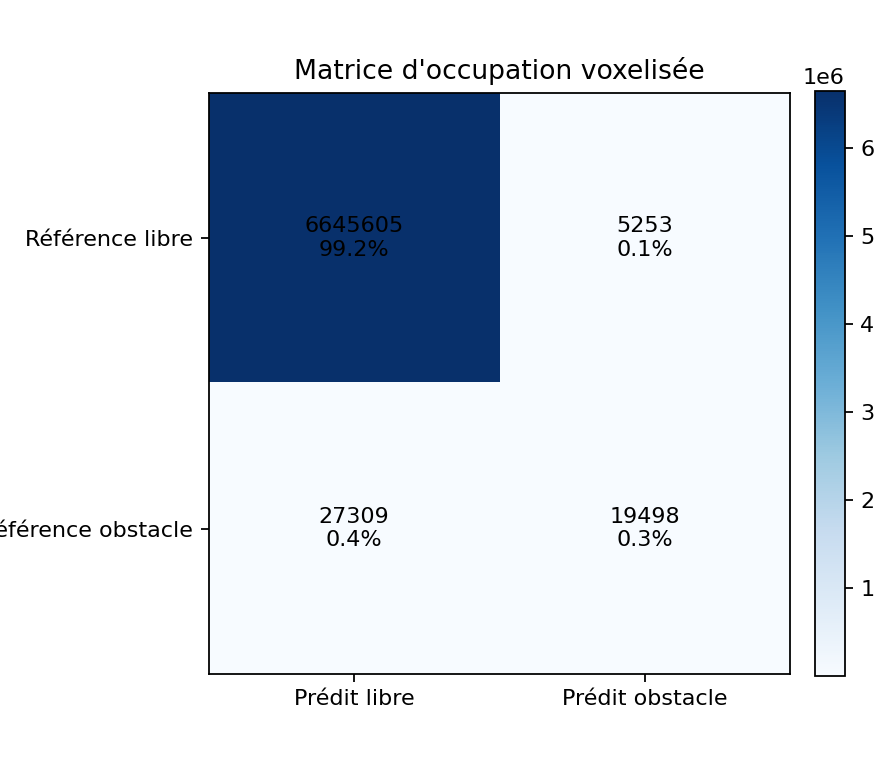


-- renders_grid.png


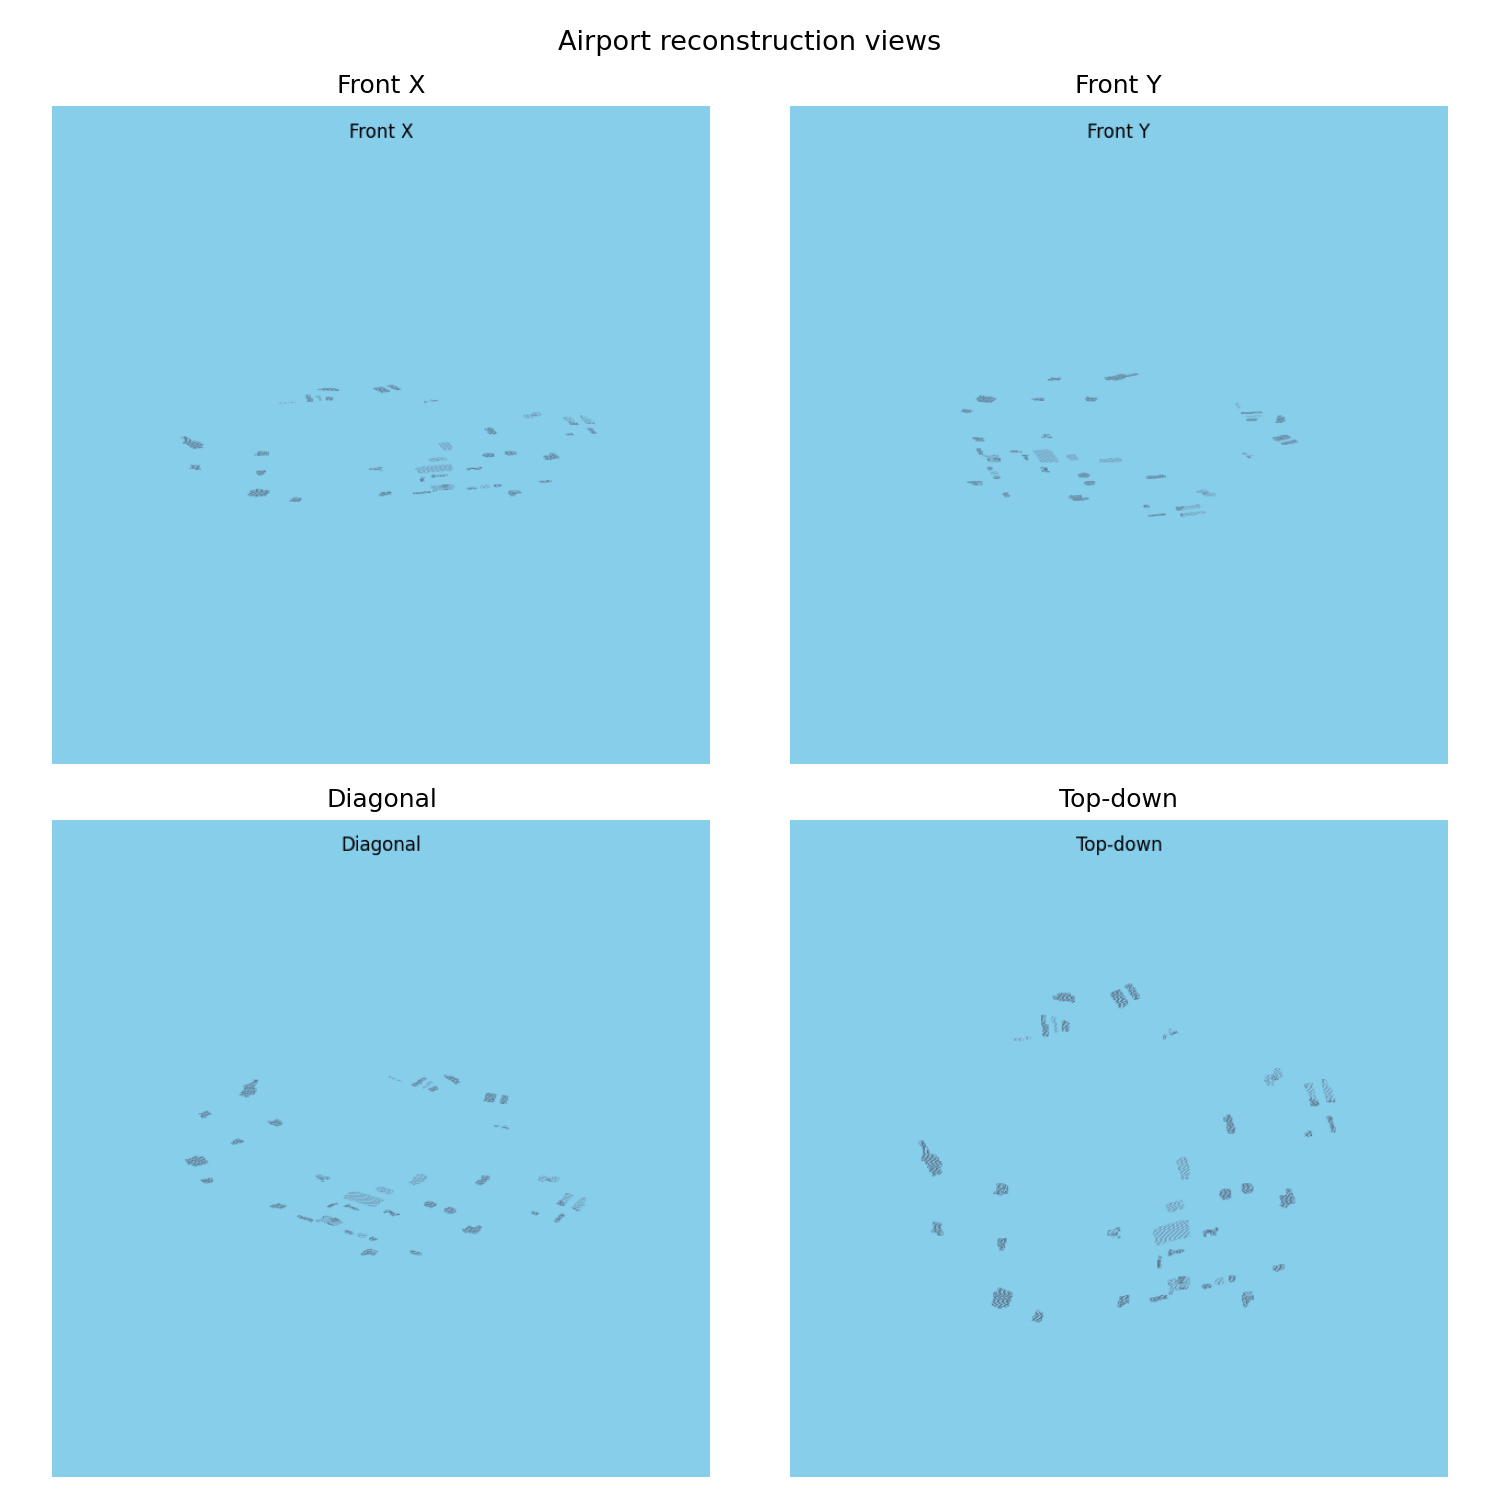


-- sdf_slice_z005.png


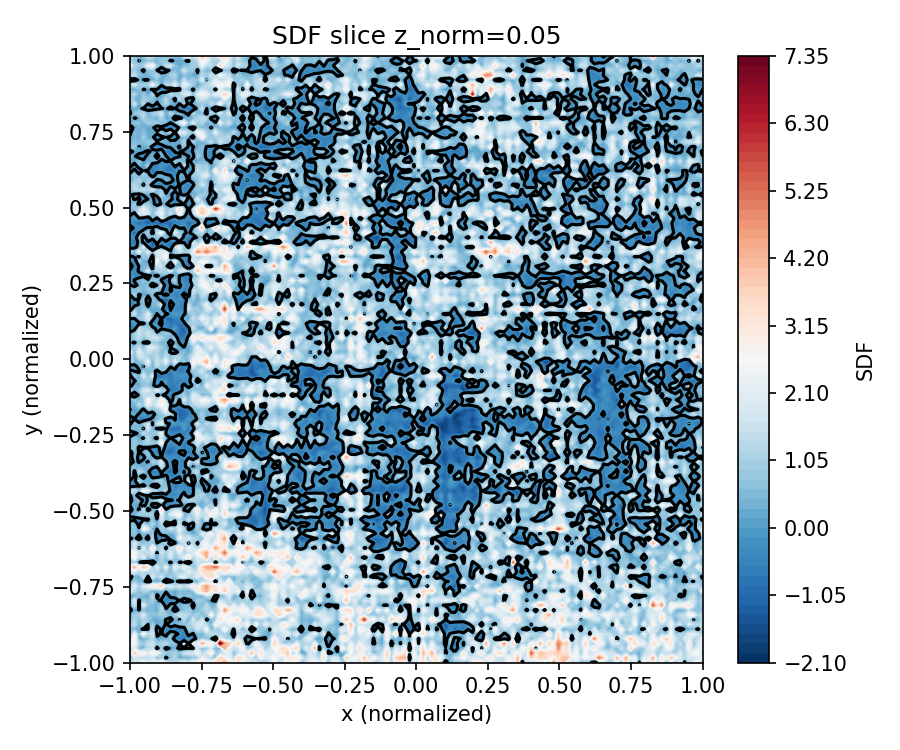


-- sdf_slice_z020.png


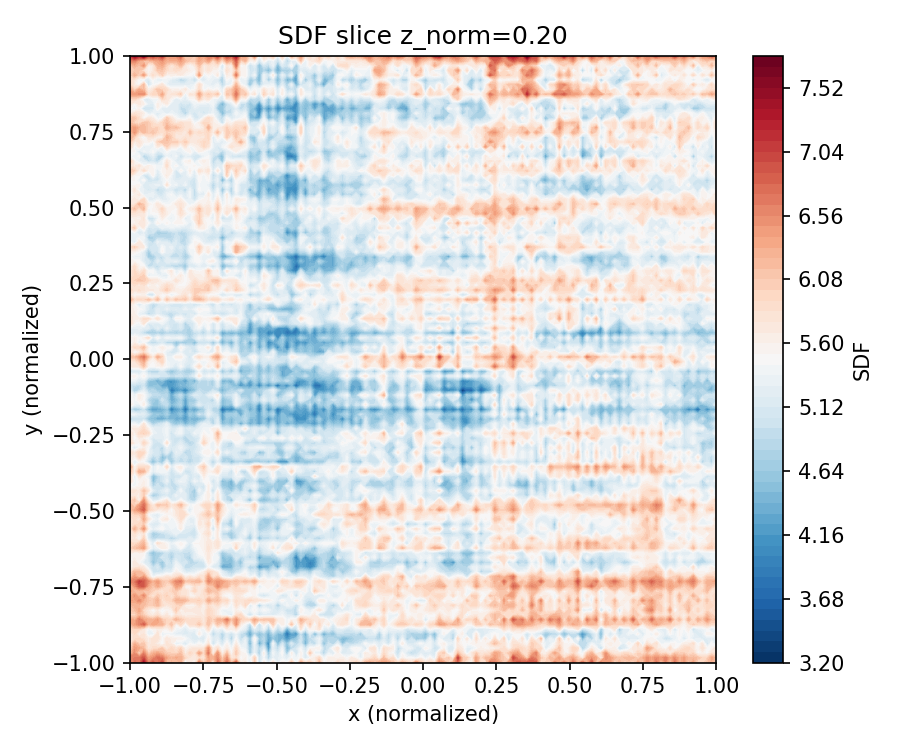


-- sdf_slice_z050.png


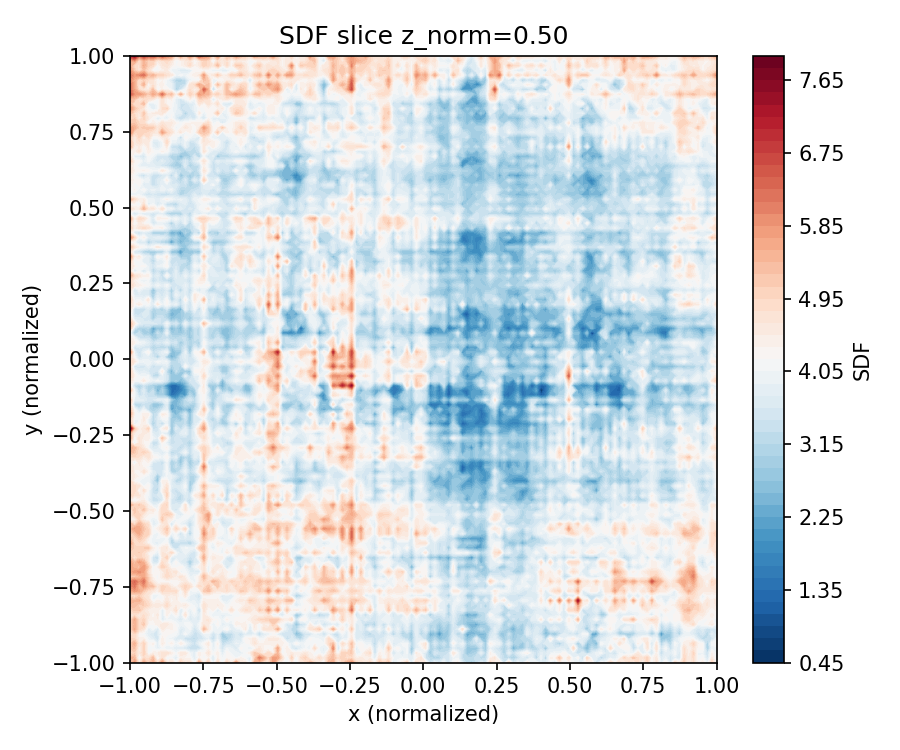


-- flyover.mp4


In [13]:
import json
from pathlib import Path
from IPython.display import Image, Video, display

metrics = json.loads(Path("outputs/reconstruction_metrics.json").read_text(encoding="utf-8"))
print("Métriques de reconstruction :")
print(json.dumps(metrics, indent=2, ensure_ascii=False))

for name in [
    "training_loss.png",
    "monitoring_curves.png",
    "reconstruction_comparison.png",
    "occupancy_confusion_matrix.png",
    "renders_grid.png",
    "sdf_slice_z005.png",
    "sdf_slice_z020.png",
    "sdf_slice_z050.png",
]:
    path = Path("outputs") / name
    if path.exists():
        print("\n--", name)
        display(Image(filename=str(path), width=720))

video_path = Path("outputs/flyover.mp4")
if video_path.exists():
    print("\n-- flyover.mp4")
    display(Video(str(video_path), embed=True))


## Cell 14 - Génération du masque d'obstacles


In [14]:
!python generate_mask.py --config {RUNTIME_CONFIG_FILE} --checkpoint {SELECTED_CHECKPOINT}

Device: cuda

=== Generating obstacle mask ===
  Using cleaned occupancy grid from evaluation.
  Obstacle cells: 24,751 / 6,697,665  (0.4%)
  Grid spacing  : dx=9.99 m, dy=10.34 m, dz=0.75 m
  Mask saved → /content/deepsdf_airport/outputs/obstacle_mask.pt  shape=(1, 1, 65, 321, 321)
  SDF grid saved → /content/deepsdf_airport/outputs/sdf_grid.npy
  Mask metadata saved → /content/deepsdf_airport/outputs/obstacle_mask_metadata.json
  Mask slice → /content/deepsdf_airport/outputs/mask_slice_z5pct.png
  Mask slice → /content/deepsdf_airport/outputs/mask_slice_z25pct.png
  Mask slice → /content/deepsdf_airport/outputs/mask_slice_z50pct.png

COPY-PASTE: how to use with wind.py

import sys, torch
sys.path.insert(0, r"/content/deepsdf_airport/prof_files")
from wind import MassConsistentWindSolverNumerical

mask = torch.load(r"/content/deepsdf_airport/outputs/obstacle_mask.pt").cuda()        # (1,1,65,321,321)

dx, dy, dz = 9.99, 10.34, 0.75       # metres
solver = MassConsistentWindSolverNumer

## Cell 15 - Contrôle qualité complet


In [15]:
import json
from pathlib import Path
import torch

outputs_dir = Path("outputs")
required_paths = [
    outputs_dir / "reconstructed_mesh.obj",
    outputs_dir / "reconstruction_metrics.json",
    outputs_dir / "reconstruction_cleaning.json",
    outputs_dir / "occupancy_confusion_matrix.png",
    outputs_dir / "renders_grid.png",
    outputs_dir / "flyover.mp4",
    outputs_dir / "obstacle_mask.pt",
]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError(f"Sorties manquantes : {missing}")

metrics = json.loads((outputs_dir / "reconstruction_metrics.json").read_text(encoding="utf-8"))
print("Valeurs clés :")
for key in [
    "chamfer_l1_m",
    "hausdorff_approx_m",
    "occupancy_iou",
    "occupancy_precision",
    "occupancy_recall",
    "predicted_obstacle_voxels",
    "reference_obstacle_voxels",
]:
    print(f"  {key}: {metrics.get(key)}")

mask = torch.load(outputs_dir / "obstacle_mask.pt", map_location="cpu")
obstacle_voxels = int((mask < 0.5).sum().item())
total_voxels = int(mask.numel())
print(f"\nObstacle voxels: {obstacle_voxels} / {total_voxels}")
assert obstacle_voxels > 0, "Masque vide."


Valeurs clés :
  chamfer_l1_m: 123.69040116245327
  hausdorff_approx_m: 675.2299937400601
  occupancy_iou: 0.37452938916634654
  occupancy_precision: 0.7877661508625914
  occupancy_recall: 0.4165616253979106
  predicted_obstacle_voxels: 24751
  reference_obstacle_voxels: 46807

Obstacle voxels: 24751 / 6697665


## Cell 16 - Test d'intégration avec wind.py


In [16]:
import sys
import torch
import yaml
from pathlib import Path

prof_dir = Path("prof_files")
if not (prof_dir / "wind.py").exists():
    print("wind.py introuvable dans prof_files")
else:
    sys.path.insert(0, str(prof_dir))
    from wind import MassConsistentWindSolverNumerical

    mask = torch.load(Path("outputs/obstacle_mask.pt"), map_location="cpu")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    mask = mask.to(device)

    with open(RUNTIME_CONFIG_FILE, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)
    d = cfg["domain"]
    dx = (d["x_max"] - d["x_min"]) / (d["grid_nx"] - 1)
    dy = (d["y_max"] - d["y_min"]) / (d["grid_ny"] - 1)
    dz = d["z_max"] / (d["grid_nz"] - 1)

    solver = MassConsistentWindSolverNumerical(dx=dx, dy=dy, dz=dz, device=device)
    u0 = torch.full_like(mask, 5.0)
    v0 = torch.zeros_like(mask)
    w0 = torch.zeros_like(mask)
    u, v, w, sigma, K = solver.adjust_wind_field(u0, v0, w0, mask)

    print("Test d'intégration terminé")
    print("  shape u :", tuple(u.shape))
    print("  max |u| :", float(u.abs().max().item()))

Test d'intégration terminé
  shape u : (1, 1, 65, 321, 321)
  max |u| : 7.023046016693115


## Cell 17 - Sauvegarde finale vers Drive


In [17]:
import shutil
from pathlib import Path

DRIVE_RUN_DIR.mkdir(parents=True, exist_ok=True)

dirs_to_copy = ["outputs", "checkpoints", "data/meshes", "data/sdf_dataset"]
for rel in dirs_to_copy:
    src = WORK_DIR / rel
    dst = DRIVE_RUN_DIR / rel
    if dst.exists():
        shutil.rmtree(dst)
    if src.exists():
        shutil.copytree(src, dst)

files_to_copy = [
    WORK_DIR / BASE_CONFIG_FILE,
    WORK_DIR / RUNTIME_CONFIG_FILE,
    WORK_DIR / RUNTIME_CONFIG_FILE.replace(".yaml", "_preparation.json"),
    WORK_DIR / "data_sources" / "airport_study.alaqs",
    WORK_DIR / "COLAB_TRAINING_final.ipynb",
]
for path in files_to_copy:
    if path.exists():
        dst = DRIVE_RUN_DIR / path.relative_to(WORK_DIR)
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(path, dst)

print("Sauvegarde finale terminée :", DRIVE_RUN_DIR)

Sauvegarde finale terminée : /content/drive/MyDrive/deepsdf_airport/COLAB_RUN_final
